In [207]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

In [208]:
def rho(x,y,z,e,p,q,rho0,s,a,b):
    """
    Calculate density value based on input coordinates and parameters.

    Parameters:
    x (float or array-like): x-coordinate(s) of the point(s).
    y (float or array-like): y-coordinate(s) of the point(s).
    z (float or array-like): z-coordinate(s) of the point(s).
    e (float): Parameter describing the disky/boxiness of the triaxial body.
    p (float): Axis ratio b/a.
    q (float): Axis ratio c/a.
    rho0 (float): Normalization parameter for density.
    s (float): Scale radius.
    a (float): Power-law exponent.
    b (float): Power-law exponent.

    Returns:
    float or array-like: Density value(s) at the given coordinates.

    Formula:
    The function calculates density value(s) based on the input coordinates (x, y, z) and parameters (e, p, q, rho0, s, a, b)
    using the following formula:

        r = ((|x|^(2 - e) + (|y| / p)^(2 - e) + (|z| / q)^(2 - e)))^(1/(2-e))
        rho = rho0 / ((r / s)^a * (1 + (r / s))^(b - a))

    where:
        |x|, |y|, |z|: Absolute values of the coordinates.
        e: Exponent parameter.
        p, q: Scaling parameters for x and y coordinates.
        rho0: Normalization parameter for density.
        s: Scaling parameter for distance.
        a, b: Shape parameters.
        r: Distance metric calculated based on the input coordinates.
        rho: Density value calculated based on the input parameters and coordinates.
    """
    r = ((jnp.abs(x)**(2 - e) + (jnp.abs(y) / p)**(2 - e) + (jnp.abs(z) / q)**(2 - e)))**(1/(2-e))
    den = rho0 / ((r/s)**a*(1+(r/s))**(b-a))
    #den = np.round(den, decimals=6)
    return den

In [209]:
def projection(density_mat):
    """
    Returns the 2D projection of a 3D density matrix along the z-axis.

    Parameters:
    - density_mat (numpy.ndarray): The 3D density matrix representing the density distribution.
                                   The shape of the matrix should be (M, N, K), where M, N, and K
                                   are the dimensions along the x, y, and z axes respectively.

    Returns:
    float or array-like: Projected Density value(s) along the z-axis.

    This function calculates the projection of the given density matrix along the z-axis,
    summing up the values along the z-axis to produce a 2D array. 
    """
    projection_z_axis = jnp.sum(density_mat, axis = 2)
    return projection_z_axis

In [210]:
def plot_img(proj_density_mat, title = ''):
    """
    Plot a 2D image with a logarithmically scaled colour bar.

    Parameters:
    - proj_density_mat (numpy.ndarray): The 2D density matrix representing the density distribution projected along the z-axis.
                                   

    Returns:
    None

    This function uses Plotly matplotlib
    to create and display an image plot of the projected density with a logarithmically scaled colour bar..
    """
    plt.imshow(proj_density_mat, origin= 'lower')
    plt.colorbar(label='Color Scale')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.show()

In [211]:
x_size = 2
y_size = 2
z_size = 2

x = [1,2]
y = [1,2]
z = [1,2]

densities = np.zeros((x_size, y_size, z_size))

for k in range(x_size):
    for j in range(y_size):
        for i in range(z_size):
            x_val = x[k]
            y_val = y[j]
            z_val = z[i]
            # Compute the density using rho_projected for each scalar x, y, z value
            densities[i, j, k] = str(x_val)+ str(y_val)+ str(z_val)

In [212]:
densities

array([[[111., 211.],
        [121., 221.]],

       [[112., 212.],
        [122., 222.]]])

In [213]:
densities[:,:,0] #x

array([[111., 121.],
       [112., 122.]])

In [214]:
densities[0,:,:] #z

array([[111., 211.],
       [121., 221.]])

In [215]:
densities[:,0,:] #y

array([[111., 211.],
       [112., 212.]])

In [216]:
x1, y1, z1 = np.meshgrid([1,2,3],
                      [4,5,6],
                      [7,8,9], indexing='ij')

densities1 = np.zeros((x_size, y_size, z_size))


for k in range(x_size):
    for i in range(y_size):
        for j in range(z_size):
            x_val, y_val, z_val = x1[k, i, j], y1[k, i, j], z1[k, i, j]
            # Compute the density using rho_projected for each scalar x, y, z value
            densities1[k, i, j] = str(x_val)+ str(y_val)+ str(z_val)

In [217]:
densities1[:,:,1] #z

array([[148., 158.],
       [248., 258.]])

In [218]:
densities1[0,:,:] #x

array([[147., 148.],
       [157., 158.]])

In [219]:
densities1[1,:,:] #x

array([[247., 248.],
       [257., 258.]])

In [220]:
densities1[:,1,:] #y

array([[157., 158.],
       [257., 258.]])

In [221]:
densities1[:,0,:] #y

array([[147., 148.],
       [247., 248.]])

In [222]:
array_3d = np.stack((x1, y1, z1), axis=-1)
array_3d

array([[[[1, 4, 7],
         [1, 4, 8],
         [1, 4, 9]],

        [[1, 5, 7],
         [1, 5, 8],
         [1, 5, 9]],

        [[1, 6, 7],
         [1, 6, 8],
         [1, 6, 9]]],


       [[[2, 4, 7],
         [2, 4, 8],
         [2, 4, 9]],

        [[2, 5, 7],
         [2, 5, 8],
         [2, 5, 9]],

        [[2, 6, 7],
         [2, 6, 8],
         [2, 6, 9]]],


       [[[3, 4, 7],
         [3, 4, 8],
         [3, 4, 9]],

        [[3, 5, 7],
         [3, 5, 8],
         [3, 5, 9]],

        [[3, 6, 7],
         [3, 6, 8],
         [3, 6, 9]]]])

In [223]:
array_3d[0,0,:] # equivalent to the indexing we did in gradient map

array([[1, 4, 7],
       [1, 4, 8],
       [1, 4, 9]])

In [224]:
from scipy.spatial.transform import Rotation as R

rotation_z_90 = R.from_euler('z', 90, degrees=True)
shape = array_3d.shape
points = array_3d.reshape(-1, 3)
rotated_array_3d = rotation_z_90.apply(points)
rotated_array_3d = rotated_array_3d.reshape(shape)
rotated_array_3d

array([[[[-4.,  1.,  7.],
         [-4.,  1.,  8.],
         [-4.,  1.,  9.]],

        [[-5.,  1.,  7.],
         [-5.,  1.,  8.],
         [-5.,  1.,  9.]],

        [[-6.,  1.,  7.],
         [-6.,  1.,  8.],
         [-6.,  1.,  9.]]],


       [[[-4.,  2.,  7.],
         [-4.,  2.,  8.],
         [-4.,  2.,  9.]],

        [[-5.,  2.,  7.],
         [-5.,  2.,  8.],
         [-5.,  2.,  9.]],

        [[-6.,  2.,  7.],
         [-6.,  2.,  8.],
         [-6.,  2.,  9.]]],


       [[[-4.,  3.,  7.],
         [-4.,  3.,  8.],
         [-4.,  3.,  9.]],

        [[-5.,  3.,  7.],
         [-5.,  3.,  8.],
         [-5.,  3.,  9.]],

        [[-6.,  3.,  7.],
         [-6.,  3.,  8.],
         [-6.,  3.,  9.]]]])

In [225]:
points

array([[1, 4, 7],
       [1, 4, 8],
       [1, 4, 9],
       [1, 5, 7],
       [1, 5, 8],
       [1, 5, 9],
       [1, 6, 7],
       [1, 6, 8],
       [1, 6, 9],
       [2, 4, 7],
       [2, 4, 8],
       [2, 4, 9],
       [2, 5, 7],
       [2, 5, 8],
       [2, 5, 9],
       [2, 6, 7],
       [2, 6, 8],
       [2, 6, 9],
       [3, 4, 7],
       [3, 4, 8],
       [3, 4, 9],
       [3, 5, 7],
       [3, 5, 8],
       [3, 5, 9],
       [3, 6, 7],
       [3, 6, 8],
       [3, 6, 9]])

In [226]:
rotated_array_3d_single_columns = np.empty_like(array_3d,dtype=float)
for i in range(shape[0]):
    for j in range(shape[1]):
        column = array_3d[i, j, :]  # Extract column along the z-direction
        rotated_column = rotation_z_90.apply(column)  # Apply rotation to the column
        rotated_array_3d_single_columns[i, j, :] = rotated_column  # Store rotated column back

rotated_array_3d_single_columns

array([[[[-4.,  1.,  7.],
         [-4.,  1.,  8.],
         [-4.,  1.,  9.]],

        [[-5.,  1.,  7.],
         [-5.,  1.,  8.],
         [-5.,  1.,  9.]],

        [[-6.,  1.,  7.],
         [-6.,  1.,  8.],
         [-6.,  1.,  9.]]],


       [[[-4.,  2.,  7.],
         [-4.,  2.,  8.],
         [-4.,  2.,  9.]],

        [[-5.,  2.,  7.],
         [-5.,  2.,  8.],
         [-5.,  2.,  9.]],

        [[-6.,  2.,  7.],
         [-6.,  2.,  8.],
         [-6.,  2.,  9.]]],


       [[[-4.,  3.,  7.],
         [-4.,  3.,  8.],
         [-4.,  3.,  9.]],

        [[-5.,  3.,  7.],
         [-5.,  3.,  8.],
         [-5.,  3.,  9.]],

        [[-6.,  3.,  7.],
         [-6.,  3.,  8.],
         [-6.,  3.,  9.]]]])

In [227]:
np.array_equal(rotated_array_3d_single_columns,rotated_array_3d)

True

In [228]:
array_3d[0, 0, :]

array([[1, 4, 7],
       [1, 4, 8],
       [1, 4, 9]])

In [229]:
a = 1
b = 4
array = np.array([7, 8, 9])


result_array = np.column_stack((np.full_like(array, a), np.full_like(array, b), array))
result_array

array([[1, 4, 7],
       [1, 4, 8],
       [1, 4, 9]])

In [230]:
result_array[0][0]

1

In [231]:
s = 1. 
e = 0.
p = 0.8
q = 0.6
a = 2.
b = 4.
rho0 = 0.001


# Define the size of your 3D matrix
x_size, y_size, z_size = 10, 10, 10

# Create 3D coordinates
x, y, z = np.meshgrid(np.linspace(-0.01, 0.01, x_size),
                      np.linspace(-0.01, 0.01, y_size),
                      np.linspace(-0.01, 0.01, z_size), indexing = 'ij')



array_3d = np.stack((x, y, z), axis=-1)
rotation_z_90 = R.from_euler('z', 45, degrees=True)
shape = array_3d.shape
points = array_3d.reshape(-1, 3)
rotated_array_3d = rotation_z_90.apply(points)
rotated_array_3d = rotated_array_3d.reshape(shape)

In [232]:
densities = np.zeros((x_size, y_size,z_size))

for k in range(x_size):
    for i in range(y_size):
        for j in range(z_size):
            x_val = rotated_array_3d[k,i,j][0]
            y_val = rotated_array_3d[k,i,j][1]
            z_val = rotated_array_3d[k,i,j][2]
            # Compute the density using rho_projected for each scalar x, y, z value
            densities[k, i, j] = rho(x_val, y_val, z_val, e, p, q, rho0, s, a, b)

In [233]:
proj = projection(densities)
proj

Array([[ 23.768398,  28.551138,  34.114716,  40.07138 ,  45.458355,
         48.770397,  48.72628 ,  45.345016,  39.927616,  33.97178 ],
       [ 28.551138,  35.482872,  44.173126,  54.282055,  64.01924 ,
         69.62383 ,  67.81852 ,  59.754406,  49.488228,  39.927616],
       [ 34.114716,  44.173126,  58.142723,  76.74013 ,  97.244736,
        108.201126,  98.99544 ,  78.760826,  59.754406,  45.345016],
       [ 40.07138 ,  54.282055,  76.74013 , 113.80039 , 169.26527 ,
        196.87129 , 149.13187 ,  98.99544 ,  67.81852 ,  48.72628 ],
       [ 45.458355,  64.01924 ,  97.244736, 169.26527 , 370.0099  ,
        437.3297  , 196.87129 , 108.201126,  69.62383 ,  48.770397],
       [ 48.770397,  69.62383 , 108.201126, 196.87129 , 437.3297  ,
        370.0099  , 169.26527 ,  97.244736,  64.01924 ,  45.458355],
       [ 48.72628 ,  67.81852 ,  98.99544 , 149.13187 , 196.87129 ,
        169.26527 , 113.80039 ,  76.74013 ,  54.282055,  40.07138 ],
       [ 45.345016,  59.754406,  78.76082

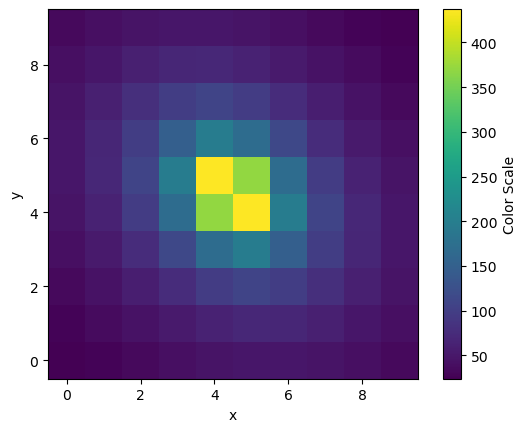

In [234]:
plot_img(proj)